# The PETDataFrame

A PET run keeps its data in three tables -- the observed data, its variance,
and the ensemble prediction -- plus the adjoints, when the simulator produces
them. All four are
`PETDataFrame` (`misc/structures/structures.py`), a `pandas.DataFrame` subclass
that adds the handful of operations PET needs and keeps everything pandas
already gives you.

The reason it exists is that these tables are *ragged*. A cell is not a number:
it holds whatever one data type produced at one report point -- a well rate (a
scalar), a seismic vintage (an array of thousands of values), or nothing at all.
An analysis, meanwhile, wants a plain `(nd, ne)` matrix with the rows in a fixed
order, and wants to be sure the observation vector, the variance vector and the
prediction matrix are indexed the same way.

`PETDataFrame` is what sits between those two views. This tutorial goes through
what it can do.

## The table

Four report dates, two well rates and a seismic response that only exists at two
of them.

In [1]:
import datetime as dt

import numpy as np
import pandas as pd

from misc.structures import PETDataFrame

dates = pd.to_datetime(["2023-02-05", "2024-03-11", "2025-04-15", "2026-05-20"])

obs = PETDataFrame(
    {
        "WOPR:PRO1": [2578.2, 3253.9, 2454.2, 2794.8],
        "WWPR:PRO1": [0.002, 0.037, 0.481, 2.941],
        "SEISMIC": [
            None,
            np.array([0.11, 0.07, 0.15, 0.09]),
            None,
            np.array([0.19, 0.12, 0.23, 0.14]),
        ],
    },
    index=dates,
    name="observed",
)
obs.index.name = "dates"
obs

,WOPR:PRO1,WWPR:PRO1,SEISMIC
dates,,,
2023-02-05,2578.2,0.002,None
2024-03-11,3253.9,0.037,"[0.11, 0.07, 0.15, 0.09]"
2025-04-15,2454.2,0.481,None
2026-05-20,2794.8,2.941,"[0.19, 0.12, 0.23, 0.14]"


`name`, `is_ensemble` and the scaling parameters are declared in `_metadata`, so
they survive slicing, copying and arithmetic -- more on that at the end.

In [2]:
obs.name, obs.is_ensemble, obs.is_scaled

('observed', False, False)

## `to_matrix()`: one table, one vector

This is the method the whole class is built around. It walks the table and
returns the numbers as an array, flattening any cell that holds one.

In [3]:
d = obs.to_matrix()
print(d.shape, d.dtype)
d

(16,) float64


array([2.5782e+03, 2.0000e-03, 3.2539e+03, 3.7000e-02, 1.1000e-01,
       7.0000e-02, 1.5000e-01, 9.0000e-02, 2.4542e+03, 4.8100e-01,
       2.7948e+03, 2.9410e+00, 1.9000e-01, 1.2000e-01, 2.3000e-01,
       1.4000e-01])

Sixteen numbers out of a 4x3 table: two scalars at every date, plus four seismic
values at each of the two dates that have them, and nothing for the two empty
cells.

Two flags control the edges:

| flag | default | effect |
| --- | --- | --- |
| `filter` | `True` | skip cells that are entirely missing (`None`/`NaN`) |
| `squeeze` | `True` | return `(nd,)` rather than `(nd, 1)` |

In [4]:
print("filter=True  ", obs.to_matrix().shape, obs.to_matrix().dtype)
print("filter=False ", obs.to_matrix(filter=False).shape, obs.to_matrix(filter=False).dtype)
print("squeeze=False", obs.to_matrix(squeeze=False).shape)

filter=True   (16,) float64
filter=False  (18,) object
squeeze=False (16, 1)


Keeping the empty cells forces an object array, which is why `filter=True` is
the default: the analysis wants floats.

The row order is worth knowing before you write anything that reasons about
individual rows. It is **time-major** -- the table is walked row by row, so the
data types interleave within each report point rather than being blocked
together. `to_series()` shows the same ordering with its labels attached:

In [5]:
obs.to_series()

dates       datatype 
2023-02-05  WOPR:PRO1                      2578.2
            WWPR:PRO1                       0.002
            SEISMIC                          None
2024-03-11  WOPR:PRO1                      3253.9
            WWPR:PRO1                       0.037
            SEISMIC      [0.11, 0.07, 0.15, 0.09]
2025-04-15  WOPR:PRO1                      2454.2
            WWPR:PRO1                       0.481
            SEISMIC                          None
2026-05-20  WOPR:PRO1                      2794.8
            WWPR:PRO1                       2.941
            SEISMIC      [0.19, 0.12, 0.23, 0.14]
dtype: object

## Reading data in

The observed data of a real case is a CSV, and `from_csv` is a thin wrapper over
`pd.read_csv` that hands back a `PETDataFrame`. This is the file the
[TinyBox PIPT tutorial](https://python-ensemble-toolbox.github.io/PET/tutorials/pipt/TinyBox/tutorial_pipt)
assimilates:

In [6]:
tinybox = PETDataFrame.from_csv(
    "../pipt/TinyBox/data.csv", index_col=0, parse_dates=True
)

print(type(tinybox).__name__, tinybox.shape, "->", tinybox.to_matrix().shape)
tinybox.iloc[:4, :4]

PETDataFrame (10, 7) -> (70,)


,WOPR:PRO1,WWPR:PRO1,WOPR:PRO2,WWPR:PRO2
dates,,,,
2023-02-05,2578.204232,-0.002049,2074.939645,0.002560
2024-03-11,3253.902190,0.037153,2180.334086,0.000093
2025-04-15,2454.249283,0.480702,2472.084127,0.044738
2026-05-20,2794.807868,2.940781,2663.894066,0.296100


`from_pickle` does the same for a pickled frame, and `from_pandas` adopts a
frame you already have, carrying over its `attrs` -- any units or provenance you
hung on it -- which plain construction drops.

## `merge_dataframes()`: one table per member, one table for the ensemble

The simulator returns one table per ensemble member. `merge_dataframes` stacks
them into a single table whose cells hold the ensemble: a scalar becomes a
`(ne,)` array, a field becomes `(nx, ne)`.

This is exactly what `ensemble.calc_prediction` does with the raw simulator
output, and with the adjoints beside it.

In [7]:
rng = np.random.default_rng(4)
ne = 20


def one_member():
    """A single member's forecast, in the shape a simulator returns it."""
    df = pd.DataFrame(
        {
            "WOPR:PRO1": obs["WOPR:PRO1"].to_numpy() * rng.normal(1, 0.05, 4),
            "WWPR:PRO1": obs["WWPR:PRO1"].to_numpy() * rng.normal(1, 0.30, 4),
            "SEISMIC": [
                None,
                obs.at[dates[1], "SEISMIC"] + rng.normal(0, 0.02, 4),
                None,
                obs.at[dates[3], "SEISMIC"] + rng.normal(0, 0.02, 4),
            ],
        },
        index=dates,
    )
    df.index.name = "dates"
    return df


pred = PETDataFrame.merge_dataframes([one_member() for _ in range(ne)])

print("is_ensemble :", pred.is_ensemble)
print("scalar cell :", pred.at[dates[0], "WOPR:PRO1"].shape)
print("field cell  :", pred.at[dates[1], "SEISMIC"].shape)

is_ensemble : True
scalar cell : (20,)
field cell  : (4, 20)


The merge is strict about geometry: every member must carry the same index and
the same columns, or it raises rather than quietly aligning. And because
`is_ensemble` is now set, `to_matrix()` knows the last axis of each cell is the
ensemble and gives back a matrix instead of a longer vector:

In [8]:
Y = pred.to_matrix()
Y.shape

(16, 20)

Sixteen rows again -- the same sixteen, in the same order, as the observation
vector. That correspondence is the point of the class.

## Three frames, one geometry

All three tables are built on the same index and columns -- the variance
cell-for-cell on the data, the prediction put there by `filter_dataframe` -- so
`to_matrix()` walks them in the same order and the data misfit is a one-liner
with no bookkeeping:

In [9]:
# Variance table: same geometry as the data, None wherever the data is None.
var = PETDataFrame(
    {
        col: [
            None
            if obs.at[idx, col] is None
            else 0.01 * np.atleast_1d(np.asarray(obs.at[idx, col], float)) ** 2 + 1e-8
            for idx in obs.index
        ]
        for col in obs.columns
    },
    index=obs.index,
)

d = obs.to_matrix(squeeze=False)   # (nd, 1)
v = var.to_matrix(squeeze=False)   # (nd, 1)
Y = pred.to_matrix()               # (nd, ne)

misfit = np.sum((Y - d) ** 2 / v, axis=0)

print(f"d {d.shape}   v {v.shape}   Y {Y.shape}")
print(f"mean data misfit: {misfit.mean():.1f}")

d (16, 1)   v (16, 1)   Y (16, 20)
mean data misfit: 62.3


PET's own diagnostics are written the same way -- see `get_outlier_index` in
`pipt.misc_tools.analysis_tools`, which is this calculation plus a threshold.

The one thing to keep straight is the gaps. `filter=True` drops a row where
*that* frame is empty, so the three have to agree on where the empty cells are.
`DataReader.get_variance` guarantees it for the variance by building on
`data_df` cell for cell; a simulator reporting a vintage the data does not have
would not, and the vectors would come out different lengths.

## `filter_dataframe()`: putting the simulator on the observation grid

A simulator reports more than you assimilate: extra time steps, extra data
types. `filter_dataframe` cuts its output down to the observation table's
geometry, and it is the one line behind `sim_to_pred_data` in
`pipt.ensembles.forecast`:

```python
pred.filter_dataframe(index=self.data_df.index, columns=self.data_df.columns)
```

In [10]:
sim_dates = pd.to_datetime(
    ["2023-02-05", "2023-08-01", "2024-03-11", "2025-04-15", "2025-11-02", "2026-05-20"]
)
raw = PETDataFrame(
    {c: np.arange(6, dtype=float) for c in
     ["WOPR:PRO1", "WWPR:PRO1", "SEISMIC", "WBHP:PRO1", "WGOR:PRO1"]},
    index=sim_dates,
)
raw.index.name = "dates"

print(f"simulator output {raw.shape}")
raw.filter_dataframe(index=obs.index, columns=obs.columns)

simulator output (6, 5)


,WOPR:PRO1,WWPR:PRO1,SEISMIC
dates,,,
2023-02-05,0.0,0.0,0.0
2024-03-11,2.0,2.0,2.0
2025-04-15,3.0,3.0,3.0
2026-05-20,5.0,5.0,5.0


Selection is by *label*, and it is deliberately tolerant about how the label is
spelled. Report points arriving from a TOML config are `datetime.date` objects
while the data CSV parses to a `DatetimeIndex`; those dtypes differ, but they
select each other perfectly well:

In [11]:
report_points = pd.Index(
    [dt.date(2023, 2, 5), dt.date(2025, 4, 15)], name="dates"
)

raw.filter_dataframe(index=report_points, columns=obs.columns)

,WOPR:PRO1,WWPR:PRO1,SEISMIC
dates,,,
2023-02-05,0.0,0.0,0.0
2025-04-15,3.0,3.0,3.0


A label that genuinely is not there is an error, not a silent gap:

In [12]:
try:
    raw.filter_dataframe(index=pd.to_datetime(["2030-01-01"]))
except ValueError as exc:
    print("ValueError:", exc)

ValueError: Provided index does not match DataFrame index: "None of [DatetimeIndex(['2030-01-01'], dtype='datetime64[ns]', freq=None)] are in the [index]"


## Scaling, and keeping the derived quantities consistent

Data types in a reservoir case differ by orders of magnitude -- oil rate in the
thousands, water cut around one. `scale()` normalises each column, records what
it used, and `invert_scale()` puts it back.

In [13]:
np.random.seed(404)
rates = PETDataFrame({k: 10 * np.random.rand(5) for k in ("WOPR", "WWPR", "WBHP")})

scaled = rates.copy()
scaled.scale(type="max-min")     # or type="z-score"

print("is_scaled :", scaled.is_scaled)
print("in [0, 1] :", bool(((scaled >= 0) & (scaled <= 1)).all().all()))

restored = scaled.copy()
restored.invert_scale(type="max-min")
print("round trip:", np.allclose(restored.to_numpy(), rates.to_numpy()))

is_scaled : True
in [0, 1] : True
round trip: True


The useful part is that the parameters are kept on the frame, so anything
*derived* from the data can be scaled to match. A variance is a squared
quantity, so it takes the squared range; a sensitivity is a derivative, so it
takes the range itself:

$$\tilde{d} = \frac{d - d_{\min}}{r}, \qquad
  \tilde{\sigma}^2 = \frac{\sigma^2}{r^2}, \qquad
  \tilde{J} = \frac{J}{r}, \qquad r = d_{\max} - d_{\min}$$

Passing `minimum`/`maximum` explicitly is how you apply those:

In [14]:
r = scaled.scale_max - scaled.scale_min          # kept from the scale() call

variance = PETDataFrame({k: 0.1 * np.random.rand(5) for k in ("WOPR", "WWPR", "WBHP")})

var_scaled = variance.copy()
var_scaled.scale(type="max-min", minimum=0, maximum=r ** 2)

print("variance scaled by 1/r^2:", np.allclose(var_scaled.to_numpy(),
                                               (variance / r ** 2).to_numpy()))

variance scaled by 1/r^2: True


This is how a run keeps its pieces consistent when `scale_data` is on: the
ensemble scales the adjoints with `minimum=0, maximum=scale_max - scale_min`
taken straight off the data frame. Scaling twice is refused rather than silently
compounded:

In [15]:
try:
    scaled.scale(type="max-min")
except ValueError as exc:
    print("ValueError:", exc)

ValueError: DataFrame is already scaled, cannot apply max-min scaling again without inverting first.


## Jacobians and adjoints

When a simulator computes adjoints, a cell no longer holds a value per member --
it holds a *gradient* per member, $\partial d_i / \partial x$, of length `nx`.
The table looks the same; only the cell contents grew an axis. `is_jacobian=True`
stacks those cells instead of flattening them:

In [16]:
nx = 4
adj_dates = pd.to_datetime(["2023-02-05", "2024-03-11", "2025-04-15"])
adj_cols = ["WOPR:PRO1", "WWPR:PRO1"]


def one_member_adjoint():
    df = pd.DataFrame(
        {c: [rng.normal(size=nx) for _ in adj_dates] for c in adj_cols},
        index=adj_dates,
    )
    df.index.name = "dates"
    return df


adjoints = PETDataFrame.merge_dataframes([one_member_adjoint() for _ in range(ne)])

print("cell                     :", adjoints.at[adj_dates[0], "WOPR:PRO1"].shape, "(nx, ne)")
print("to_matrix(is_jacobian=True):", adjoints.to_matrix(is_jacobian=True).shape, "(nd, nx, ne)")
print("to_matrix()                :", adjoints.to_matrix().shape, "-- flattened, not what you want")

cell                     : (4, 20) (nx, ne)
to_matrix(is_jacobian=True): (6, 4, 20) (nd, nx, ne)
to_matrix()                : (24, 20) -- flattened, not what you want


That first shape, `(nd, nx, ne)`, is what the schemes read when a simulator sets
`compute_adjoints`; `savedata = ["adjoints"]` in the `[dataassim]` block writes
the table itself to each iteration's `assimilation_result_{i}.npz`, as records.

State variables can also be split across a `MultiIndex` column level, `(datatype,
parameter)`. `to_matrix` concatenates the parameter blocks per data type, so the
result is identical to having built one wide column in the first place:

In [17]:
wide = {}
for key in adj_cols:
    for param in ("permx", "poro"):
        wide[(key, param)] = [rng.normal(size=nx) for _ in adj_dates]

multi = pd.DataFrame(wide, index=adj_dates)
multi.columns = pd.MultiIndex.from_tuples(wide.keys())
multi.index.name = "dates"
multi = PETDataFrame.from_pandas(multi)

print("columns          :", list(multi.columns))
print("as a Jacobian    :", multi.to_matrix(is_jacobian=True).shape, "-- nx doubled to 8")
print("same as flattened:", np.array_equal(
    multi.to_matrix(is_jacobian=True),
    multi._to_singlelevel_columns().to_matrix(is_jacobian=True),
))

columns          : [('WOPR:PRO1', 'permx'), ('WOPR:PRO1', 'poro'), ('WWPR:PRO1', 'permx'), ('WWPR:PRO1', 'poro')]
as a Jacobian    : (6, 8) -- nx doubled to 8
same as flattened: True


## It is still a DataFrame

Nothing above costs you pandas. `_constructor` and `_metadata` are set so that
operations return a `PETDataFrame` with its flags intact rather than degrading
to a plain frame:

In [18]:
for label, out in [
    ("copy()", pred.copy()),
    (".loc[]", pred.loc[dates[:2]]),
    ("filter_dataframe()", pred.filter_dataframe(columns=["WOPR:PRO1"])),
    ("map()", pred.map(lambda cell: cell)),
]:
    print(f"{label:>20}: {type(out).__name__:<13} is_ensemble={out.is_ensemble}")

              copy(): PETDataFrame  is_ensemble=True
              .loc[]: PETDataFrame  is_ensemble=True
  filter_dataframe(): PETDataFrame  is_ensemble=True
               map(): PETDataFrame  is_ensemble=True


Which means the labels are there when you want to look at the ensemble, without
unpacking anything into arrays first:

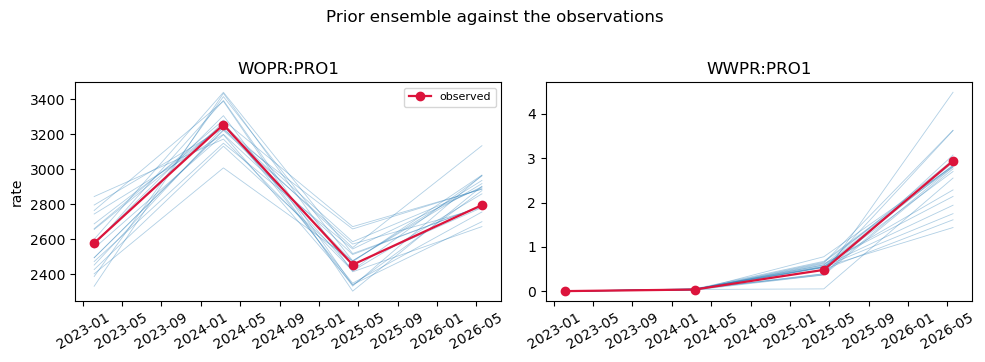

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, col in zip(axes, ["WOPR:PRO1", "WWPR:PRO1"]):
    members = np.vstack(pred[col].to_numpy())        # (ndates, ne)
    ax.plot(pred.index, members, c="tab:blue", lw=0.6, alpha=0.35)
    ax.plot(obs.index, obs[col], "o-", c="crimson", lw=1.6, label="observed")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("rate")
axes[0].legend(fontsize=8)
fig.suptitle("Prior ensemble against the observations", y=1.02)
plt.tight_layout()
plt.show()

## Where they come from in a real run

| frame | built by | cells hold |
| --- | --- | --- |
| `data_df` | `DataReader.get_data()`, from `data = "data.csv"` | the observation |
| `data_var_df` | `DataReader.get_variance()`, on `data_df`'s geometry | its variance |
| `sim_data` | `merge_dataframes()` over the simulator's per-member output, on demand | `(ne,)` or `(nx, ne)` |

On the analysis path the data are matrices, not frames. `DataLayout.from_frame(data_df)`
fixes the row order once -- label-major, then data type, empty cells skipped -- and
everything is built in that order: the ensemble's `obs_vector` and `obs_variance`
from the two frames, and `pred_data`, a `PredictedData` whose `(nd, ne)` `.matrix` is
filled straight from each member's simulator output. Adjoints are an `(nd, nx, ne)`
array with the same rows. `pred_data.to_frame()` gives the frame view back for
inspection, and `sim_data` is the full forecast as a frame, built when something asks
for it. That is why an analysis never has to think about ragged cells, missing
vintages, or what order the data types came in.

---

The state side of a run is a plain `(nx, ne)` array. Its `{name: (start, stop)}`
row map is a `StateLayout` (the ensemble's `state_layout`), which slices the matrix
back into the per-variable dictionaries a simulator expects.

In [ ]:
from misc.structures import StateLayout

state, layout = StateLayout.from_dict(
    {"permx": rng.normal(size=(10, ne)), "poro": rng.normal(size=(6, ne))}
)

print(state.shape, layout.indices)
print({k: v.shape for k, v in layout.to_dict(state).items()})
print("one member ->", {k: v.shape for k, v in layout.member_dicts(state)[0].items()})